# 04 — Global ML forecasting

Instead of one model per clinic, a **global model** learns one function across
the whole panel using lag features, rolling statistics and calendar/metadata
inputs. Global models share statistical strength across series — clinics with
short or noisy history borrow signal from similar clinics — and they scale to
hundreds of series at constant training cost.

Evaluation uses the same `RollingOriginSplitter` folds as notebook 03, so the
comparison against baselines is apples-to-apples.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

pd.set_option("display.max_columns", 80)
plt.rcParams["figure.figsize"] = (11, 4)

In [2]:
from clinic_forecast.data import generate_network_data

data_path = PROJECT_ROOT / "data" / "processed" / "clinic_daily_usage.csv"
if data_path.exists():
    usage = pd.read_csv(data_path, parse_dates=["date"])
else:
    usage = generate_network_data().usage
    usage["date"] = pd.to_datetime(usage["date"])

print(usage.shape)

(17532, 32)


## Rolling-origin evaluation

For each fold we fit the global model on the training window only, then score
the 28-day test window. Lag features for the test window are built from known
history at prediction time (`predict_known_future`), which is valid for
backtesting; a production deployment would feed predictions back recursively.

In [3]:
from clinic_forecast.metrics import compute_metrics
from clinic_forecast.models.baseline import seasonal_naive_forecast
from clinic_forecast.models.ml import GlobalMLForecaster
from clinic_forecast.validation import RollingOriginSplitter

splitter = RollingOriginSplitter(initial_train_days=365 * 3, horizon_days=28, max_folds=3)
splitter.summary(usage)

,fold_id,train_start,train_end,test_start,test_end,train_days,test_days,train_rows,test_rows
0,1,2022-01-01,2024-12-30,2024-12-31,2025-01-27,1095,28,13140,336
1,2,2022-01-01,2025-01-27,2025-01-28,2025-02-24,1123,28,13476,336
2,3,2022-01-01,2025-02-24,2025-02-25,2025-03-24,1151,28,13812,336


In [4]:
fold_rows = []
last_scored = None
for train, test, fold in splitter.split(usage):
    model = GlobalMLForecaster()
    model.fit(train)

    combined = pd.concat([train, test], ignore_index=True).sort_values(["clinic_id", "date"])
    predictions = model.predict_known_future(combined)
    predictions = predictions[predictions["date"] >= fold.test_start]

    scored = test.merge(
        predictions[["clinic_id", "date", "forecast"]], on=["clinic_id", "date"], how="inner"
    )
    naive = seasonal_naive_forecast(train=train, future=test)
    scored_naive = test.merge(naive, on=["clinic_id", "date"], how="left")

    fold_rows.append({
        "fold": fold.fold_id,
        "global_ml_wape": compute_metrics(scored["visits"], scored["forecast"]).wape,
        "seasonal_naive_wape": compute_metrics(
            scored_naive["visits"], scored_naive["forecast"]
        ).wape,
    })
    last_scored = scored

fold_results = pd.DataFrame(fold_rows)
fold_results.round(2)

,fold,global_ml_wape,seasonal_naive_wape
0,1,8.28,41.38
1,2,5.76,5.95
2,3,6.27,7.98


## Per-clinic performance on the final fold

A global model can hide poor performance on individual clinics behind a good
average — always inspect the per-series distribution.

In [5]:
from clinic_forecast.metrics import metrics_by_group

clinic_metrics = metrics_by_group(
    last_scored, group_col="clinic_id", actual_col="visits", forecast_col="forecast"
)
clinic_metrics.sort_values("wape").round(2)

,clinic_id,mae,rmse,mape,smape,wape,bias
1,CLINIC_002,2.66,5.31,1.26,1.26,1.18,-0.22
11,CLINIC_012,6.85,9.46,3.41,3.43,3.24,-2.01
9,CLINIC_010,7.80,10.07,5.53,26.13,4.70,-1.36
6,CLINIC_007,6.68,8.49,5.56,5.43,4.97,0.28
0,CLINIC_001,6.45,8.15,6.88,27.40,6.86,-2.70
10,CLINIC_011,7.95,9.78,9.58,29.40,8.62,0.46
5,CLINIC_006,9.00,12.79,9.88,36.73,8.86,1.21
8,CLINIC_009,7.66,10.47,10.62,30.22,10.48,1.13
3,CLINIC_004,8.12,11.26,11.32,16.25,10.50,3.29
7,CLINIC_008,7.75,10.11,12.17,31.71,11.08,1.48


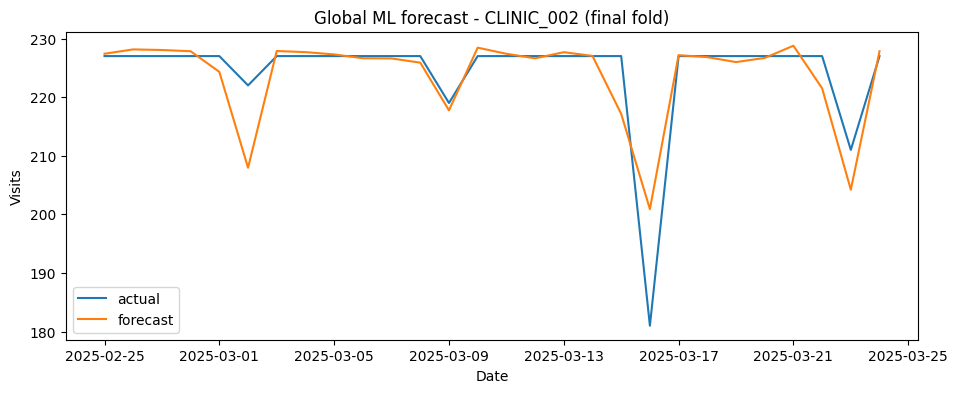

In [6]:
clinic_id = clinic_metrics.sort_values("wape").iloc[0]["clinic_id"]
example = last_scored[last_scored["clinic_id"] == clinic_id]

fig, ax = plt.subplots()
ax.plot(example["date"], example["visits"], label="actual")
ax.plot(example["date"], example["forecast"], label="forecast")
ax.set_title(f"Global ML forecast - {clinic_id} (final fold)")
ax.set_xlabel("Date")
ax.set_ylabel("Visits")
ax.legend()
plt.show()

## Optional: XGBoost

The default estimator is scikit-learn's `HistGradientBoostingRegressor`, which
provides an XGBoost-style gradient-boosted tree model without the extra
dependency. XGBoost itself is available through the optional group.

In [7]:
try:
    from xgboost import XGBRegressor

    print("XGBoost is installed. You can replace the default estimator with XGBRegressor.")
except ImportError:
    print("XGBoost is not installed. Run `poetry install --with optional` to enable it.")

XGBoost is not installed. Run `poetry install --with optional` to enable it.


## Insights

- One global model serves all 12 clinics and is evaluated on exactly the same
  rolling folds as the baselines, fold by fold.
- Compare `global_ml_wape` against `seasonal_naive_wape` per fold above: the
  global model must consistently beat the naive baseline to justify itself.
- Per-clinic WAPE varies — the upcoming evaluation utilities (shared metric
  definitions, model ranking) and conformal intervals build directly on this
  fold structure.

**Next:** notebook 05 covers optional deep-learning and foundation-model
benchmarks; notebook 06 turns forecasts into staffing decisions.